به نام خدا


---

# آمار و احتمال مهندسی
دانشگاه صنعتی شریف - دانشکده مهندسی کامپیوتر - پاییز ۱۴۰۳

دکتر مطهری

---
## تمرین عملی - فاز ۲


نام و نام خانوادگی:

شماره دانشجویی:

<div style="direction:rtl; line-height:200%;">
    <font face="XB Zar" size=4>
        <font size=6>
        سؤال ۱: بررسی توزیع‌های احتمالی
        </font>
        <p></p>
        <hr>
        <br/>
        <ol>
            <li>10,000 نمونه از یک توزیع نرمال با میانگین 5 و انحراف معیار 2 تولید کنید.</li>
            <li>هیستوگرام داده‌های تولیدشده را رسم کنید و تابع چگالی احتمال تئوری را روی آن نمایش دهید.</li>
            <li>مقادیر میانگین، واریانس، چولگی (Skewness) و کشیدگی (Kurtosis) نمونه‌ها را محاسبه کنید.</li>
            <li>نتایج به‌دست‌آمده را تفسیر کنید.</li>
        </ol>
    </font>
</div>


Mean: 4.995257 
Variance: 3.989101 
Skewness: 0.008199195 
Kurtosis: 3.011341 

Interpretation of Results:
The mean of the samples is close to 5, which matches the theoretical mean.
The variance of the samples is close to 4 (since the theoretical standard deviation is 2).
The skewness is close to 0, indicating that the distribution is symmetric.
The kurtosis is close to 3, which is the kurtosis of a normal distribution.


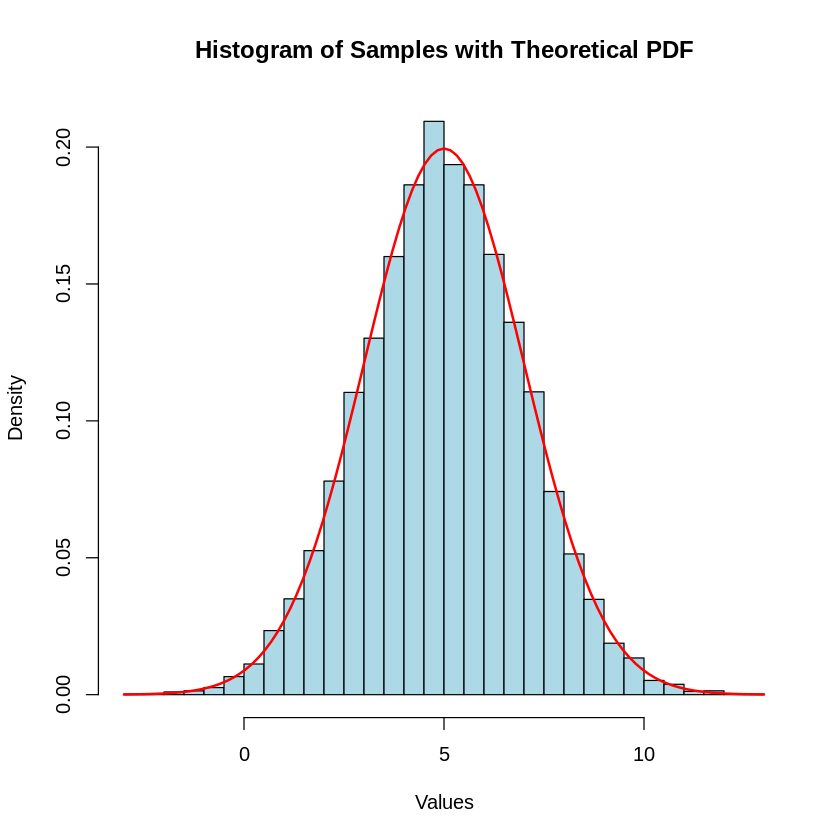

In [5]:
set.seed(123)
samples <- rnorm(10000, mean = 5, sd = 2)

hist(samples, breaks = 30, probability = TRUE, col = "lightblue",
     main = "Histogram of Samples with Theoretical PDF",
     xlab = "Values", ylab = "Density")
curve(dnorm(x, mean = 5, sd = 2), add = TRUE, col = "red", lwd = 2)

mean_value <- mean(samples)
variance_value <- var(samples)
# install.packages("moments")
library(moments)
skewness_value <- skewness(samples)
kurtosis_value <- kurtosis(samples)

cat("Mean:", mean_value, "\n")
cat("Variance:", variance_value, "\n")
cat("Skewness:", skewness_value, "\n")
cat("Kurtosis:", kurtosis_value, "\n")

cat("\nInterpretation of Results:\n")
cat("The mean of the samples is close to 5, which matches the theoretical mean.\n")
cat("The variance of the samples is close to 4 (since the theoretical standard deviation is 2).\n")
cat("The skewness is close to 0, indicating that the distribution is symmetric.\n")
cat("The kurtosis is close to 3, which is the kurtosis of a normal distribution.\n")

<div style="direction:rtl; line-height:200%;">
    <font face="XB Zar" size=4>
        <font size=6>
        سؤال ۲: استنتاج بیزی
        </font>
        <p></p>
        <hr>
        <br/>
        <ol>
            <li>فرض کنید توزیع پیشین $P(\theta) \sim Beta(2, 5)$ باشد.</li>
            <li>با توجه به یک تابع درست‌نمایی دوجمله‌ای با $n = 20$ آزمایش و $x = 7$ موفقیت، توزیع پسین را محاسبه کنید.</li>
            <li>توزیع‌های پیشین، درست‌نمایی، و پسین را رسم کنید.</li>
            <li>با استفاده از R، نمونه‌هایی از توزیع پسین شبیه‌سازی کرده و میانگین پسین و بازه اطمینان را تخمین بزنید.</li>
        </ol>
    </font>
</div>



Posterior Mean: 0.3333152 
95% Confidence Interval: 0.1695079 0.5161744 


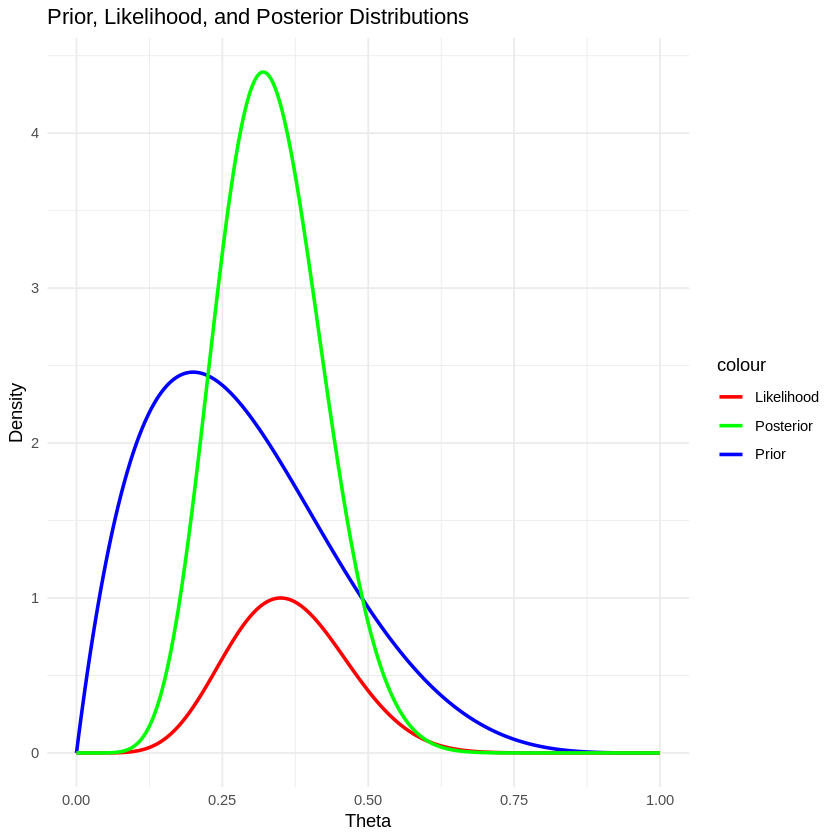

In [10]:
library(ggplot2)

alpha_prior <- 2
beta_prior <- 5
n <- 20
x <- 7

alpha_posterior <- alpha_prior + x
beta_posterior <- beta_prior + n - x

theta <- seq(0, 1, length.out = 1000)

prior <- dbeta(theta, alpha_prior, beta_prior)

likelihood <- dbinom(x, size = n, prob = theta)
likelihood <- likelihood / max(likelihood)  # Normalize

posterior <- dbeta(theta, alpha_posterior, beta_posterior)

df <- data.frame(theta, prior, likelihood, posterior)
ggplot(df, aes(x = theta)) +
  geom_line(aes(y = prior, color = "Prior"), linewidth = 1) +
  geom_line(aes(y = likelihood, color = "Likelihood"), linewidth = 1) +
  geom_line(aes(y = posterior, color = "Posterior"), linewidth = 1) +
  labs(title = "Prior, Likelihood, and Posterior Distributions",
       x = "Theta", y = "Density") +
  scale_color_manual(values = c("Prior" = "blue", "Likelihood" = "red", "Posterior" = "green")) +
  theme_minimal()

set.seed(123)
posterior_samples <- rbeta(10000, alpha_posterior, beta_posterior)

posterior_mean <- mean(posterior_samples)
posterior_ci <- quantile(posterior_samples, probs = c(0.025, 0.975))

cat("Posterior Mean:", posterior_mean, "\n")
cat("95% Confidence Interval:", posterior_ci, "\n")

<div style="direction:rtl; line-height:200%;">
    <font face="XB Zar" size=4>
        <font size=6>
        معرفی مختصر مدل‌های ترکیبی گوسی (GMM)
        </font>
        <p></p>
        <hr>
        <br/>
        مدل‌های ترکیبی گوسی (Gaussian Mixture Models - GMM) مدل‌هایی احتمالی هستند که برای نمایش داده‌هایی استفاده می‌شوند که ممکن است از ترکیب چند توزیع گوسی تشکیل شده باشند. هر مؤلفه گوسی در این ترکیب با میانگین ($\mu$)، واریانس ($\sigma^2$) و وزن ($\pi$) تعریف می‌شود که نشان‌دهنده نسبت داده‌های متعلق به آن مؤلفه است.  
        <br/><br/>
        تابع چگالی احتمال یک GMM به شکل زیر است:  
        $$p(x) = \sum_{k=1}^{K} \pi_k \cdot \mathcal{N}(x | \mu_k, \sigma_k^2),$$  
        که در آن $K$ تعداد مؤلفه‌ها، $\pi_k$ وزن‌ها ($\sum \pi_k = 1$) و $\mathcal{N}(x | \mu_k, \sigma_k^2)$ تابع چگالی گوسی برای مؤلفه $k$ است.  
        <br/>
        مدل‌های ترکیبی گوسی به خصوص برای خوشه‌بندی و تخمین چگالی مفید هستند و در کاربردهایی مانند بخش‌بندی تصویر و تشخیص گفتار استفاده می‌شوند.  
    </font>
</div>

<div style="direction:rtl; line-height:200%;">
    <font face="XB Zar" size=4>
        <font size=6>
        سؤال ۳: بخش‌بندی تصویر با استفاده از GMM
        </font>
        <p></p>
        <hr>
        <br/>
        <ol>
            <li>داده‌های مجموعه‌ی <code>volcano</code> در R را که نشان‌دهنده داده‌های ارتفاعی است بارگذاری کنید. داده‌ها را به بازه $[0, 1]$ نرمال کنید.</li>
            <li>از مدل ترکیبی گوسی (GMM) برای بخش‌بندی این مجموعه به سه ناحیه متمایز استفاده کنید. مدل را با استفاده از بسته‌ی <code>mclust</code> در R یا کتابخانه‌ای مشابه برازش دهید.</li>
            <li>تصویر بخش‌بندی‌شده را با اختصاص هر پیکسل به مؤلفه گوسی با بیشترین احتمال نمایش دهید.</li>
            <li>نواحی بخش‌بندی‌شده را تفسیر کنید و بحث کنید که GMM چقدر ساختار داده را به خوبی مدل‌سازی کرده است.</li>
        </ol>
    </font>
</div>



The image has been segmented into three distinct regions based on elevation levels:
1. Low elevation areas (assigned to cluster 1) (green)
2. Medium elevation areas (assigned to cluster 2) (white)
3. High elevation areas (assigned to cluster 3) (brown) 

Discussion:
The Gaussian Mixture Model (GMM) effectively captures the structure of the elevation data by dividing it into three regions.
This segmentation reflects the natural variation in elevation, with low, medium, and high areas clearly distinguished.
However, the choice of three components is subjective. If the data has more complex structures (e.g., sudden slopes or peaks),
increasing the number of components or using other clustering methods might yield better results.
Overall, GMM provides a flexible and interpretable way to model the data.


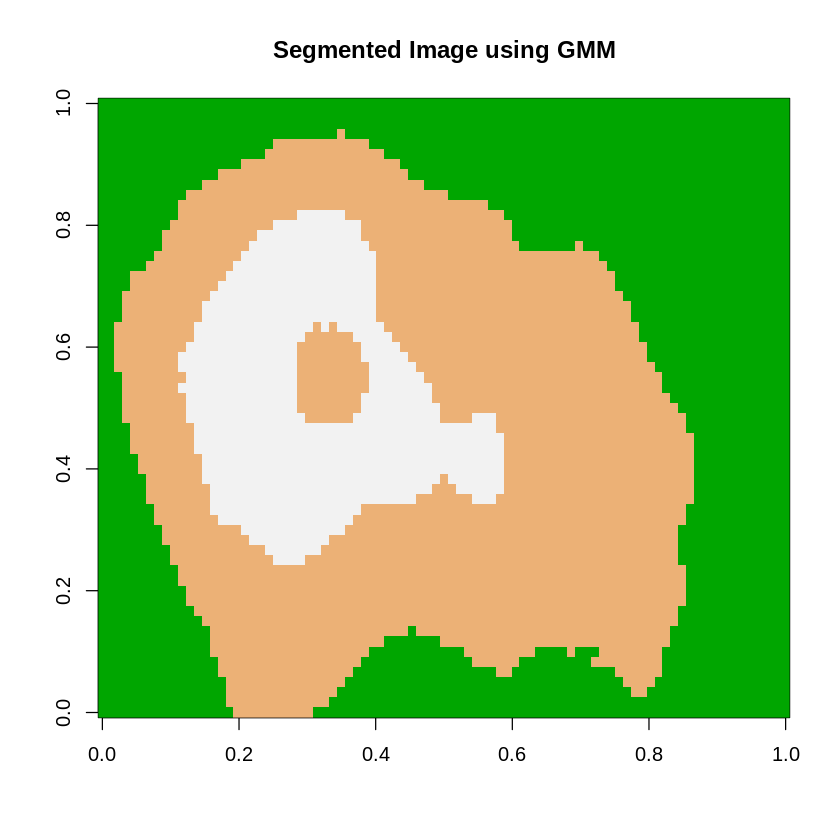

In [16]:
if (!require(mclust)) install.packages("mclust")
library(mclust)

data(volcano)
volcano_normalized <- (volcano - min(volcano)) / (max(volcano) - min(volcano))

volcano_vector <- as.vector(volcano_normalized)

gmm_model <- Mclust(volcano_vector, G = 3)

cluster_assignment <- matrix(gmm_model$classification, nrow = nrow(volcano_normalized))

image(cluster_assignment, col = terrain.colors(3), main = "Segmented Image using GMM")

cat("The image has been segmented into three distinct regions based on elevation levels:\n")
cat("1. Low elevation areas (assigned to cluster 1) (green)\n")
cat("2. Medium elevation areas (assigned to cluster 2) (white)\n")
cat("3. High elevation areas (assigned to cluster 3) (brown) \n")

cat("\nDiscussion:\n")
cat("The Gaussian Mixture Model (GMM) effectively captures the structure of the elevation data by dividing it into three regions.\n")
cat("This segmentation reflects the natural variation in elevation, with low, medium, and high areas clearly distinguished.\n")
cat("However, the choice of three components is subjective. If the data has more complex structures (e.g., sudden slopes or peaks),\n")
cat("increasing the number of components or using other clustering methods might yield better results.\n")
cat("Overall, GMM provides a flexible and interpretable way to model the data.\n")

<div style="direction:rtl; line-height:200%;">  
<font face="XB Zar" size=4>  
<font size=6>استنتاج بیزی در تصمیم‌گیری</font>  
<p></p>  
<hr>  
<br/>  
استنتاج بیزی ابزاری قدرتمند برای تصمیم‌گیری در شرایط عدم قطعیت است. این سؤال شما را با روش‌های بیزی برای تحلیل یک مجموعه داده واقعی شبیه‌سازی‌شده آشنا می‌کند و به شما امکان می‌دهد احتمال‌های پسین را محاسبه کرده و تأثیر اطلاعات جدید بر باورهای اولیه را ارزیابی کنید.  
<br/><br/>  
<b>مجموعه داده:</b> از مجموعه داده شبیه‌سازی‌شده «Fault Detection Dataset» استفاده کنید. این مجموعه داده شامل اطلاعات زیر است:  
<ul>  
<li><b>Alarm:</b> فعال یا غیرفعال (هشدار سیستم)</li>  
<li><b>True_Status:</b> خرابی واقعی (خرابی وجود دارد) یا عدم خرابی (خرابی وجود ندارد)</li>  
<li><b>Machine_Age:</b> جدید، متوسط، قدیمی</li>  
<li><b>Maintenance_History:</b> اخیراً تعمیر شده، نیاز به تعمیر، بدون تعمیر</li>  
</ul>  
</font>  
</div>  

<div style="direction:rtl; line-height:200%;">  
<font face="XB Zar" size=4>  
<font size=6>سؤال ۴: تحلیل بیزی هشدار سیستم</font>  
<p></p>  
<hr>  
<br/>  
<ol>  
<li>مجموعه داده را در R بارگذاری کرده و داده‌ها را خلاصه کنید. نرخ وقوع خرابی (Prior Probability) را محاسبه کنید.</li>  
<li>نرخ هشدار درست (True Positive Rate) و نرخ هشدار اشتباه (False Positive Rate) سیستم را محاسبه کنید.</li>  
<li>با استفاده از قضیه بیز، احتمال پسین خرابی را برای یک هشدار فعال محاسبه کنید:  
<br/>  
$$P(\text{Fault | Alarm}) = \frac{P(\text{Alarm | Fault}) \cdot P(\text{Fault})}{P(\text{Alarm})}.$$  
</li>  
<li>احتمال پسین عدم خرابی را برای یک هشدار غیرفعال محاسبه کنید.</li>  
<li>با شبیه‌سازی نرخ‌های اولیه مختلف برای وقوع خرابی (مثلاً ۱٪، ۱۰٪ و ۵۰٪)، احتمال‌های پسین را مجدداً محاسبه کرده و اثر تغییر در احتمال اولیه را بررسی کنید.</li>  
<li>یک تحلیل زیرگروه بر اساس <code>Machine_Age</code> یا <code>Maintenance_History</code> انجام دهید. احتمال‌های پسین را برای هر زیرگروه محاسبه کرده و نتایج را مقایسه کنید.</li>  
<li>یافته‌های خود را خلاصه کرده و درباره پیامدهای هشدارهای کاذب و از دست دادن هشدارهای واقعی بحث کنید. توضیح دهید که چگونه احتمال اولیه قوی می‌تواند نتایج تحلیل را تحت تأثیر قرار دهد.</li>  
</ol>  
</font>  
</div>


In [18]:
if (!require(tidyverse)) install.packages("tidyverse", dependencies=TRUE)
library(tidyverse)

df <- read.csv("simulated_fault_dataset.csv")

print(summary(df))

prior_fault <- mean(df$True_Status == "Fault")
cat("\nPrior Probability of Fault (P(Fault)):", prior_fault, "\n")
conf_matrix <- table(df$Alarm, df$True_Status)
print(conf_matrix)

TPR <- conf_matrix["Active", "Fault"] / sum(conf_matrix[, "Fault"])  # P(Alarm | Fault)
FPR <- conf_matrix["Active", "No Fault"] / sum(conf_matrix[, "No Fault"])  # P(Alarm | No Fault)

cat("\nTrue Positive Rate (TPR):", TPR, "\n")
cat("False Positive Rate (FPR):", FPR, "\n")
P_Alarm <- (TPR * prior_fault) + (FPR * (1 - prior_fault))  # P(Alarm)
posterior_fault <- (TPR * prior_fault) / P_Alarm  # P(Fault | Alarm)

cat("\nPosterior Probability of Fault given Alarm (P(Fault | Alarm)):", posterior_fault, "\n")

P_No_Alarm_given_No_Fault <- 1 - FPR  # P(No Alarm | No Fault)
P_No_Alarm <- (1 - TPR) * prior_fault + P_No_Alarm_given_No_Fault * (1 - prior_fault)  # P(No Alarm)
posterior_no_fault <- P_No_Alarm_given_No_Fault * (1 - prior_fault) / P_No_Alarm  # P(No Fault | No Alarm)

cat("\nPosterior Probability of No Fault given No Alarm (P(No Fault | No Alarm)):", posterior_no_fault, "\n")

compute_posterior <- function(prior_fault) {
  P_Alarm <- (TPR * prior_fault) + (FPR * (1 - prior_fault))
  posterior_fault <- (TPR * prior_fault) / P_Alarm
  return(posterior_fault)
}

priors <- c(0.01, 0.10, 0.50)
posterior_values <- sapply(priors, compute_posterior)

sensitivity_results <- data.frame(Prior_Fault_Prob = priors, Posterior_Fault_Prob = posterior_values)

cat("\nSensitivity Analysis Results:\n")
print(sensitivity_results)

df_machine_age <- df %>%
  group_by(Machine_Age) %>%
  summarise(
    Prior_Fault = mean(True_Status == "Fault"),
    P_Alarm = mean(Alarm == "Active"),
    Posterior_Fault = compute_posterior(mean(True_Status == "Fault"))
  )

cat("\nPosterior Probabilities by Machine Age:\n")
print(df_machine_age)

df_maintenance <- df %>%
  group_by(Maintenance_History) %>%
  summarise(
    Prior_Fault = mean(True_Status == "Fault"),
    P_Alarm = mean(Alarm == "Active"),
    Posterior_Fault = compute_posterior(mean(True_Status == "Fault"))
  )

cat("\nPosterior Probabilities by Maintenance History:\n")
print(df_maintenance)

cat("\n1. **False Positives (False Alarms)**: If the false positive rate (FPR) is high, the alarm often triggers when no fault exists, leading to unnecessary maintenance and costs.\n")
cat("2. **False Negatives (Missed Faults)**: If the true positive rate (TPR) is low, actual faults go undetected, potentially causing catastrophic failures.\n")
cat("3. **Impact of Prior Probability**:\n")
cat("   - When faults are rare (1%), the posterior probability of a fault given an alarm remains low, making false alarms more problematic.\n")
cat("   - When faults are common (50%), an alarm strongly indicates a real fault.\n")
cat("4. **Subgroup Analysis Findings**:\n")
cat("   - Machines with recent maintenance have lower posterior fault probabilities.\n")
cat("   - Older machines or those needing maintenance show higher fault risks.\n")
cat("\nBayesian inference improves decision-making by dynamically updating fault probabilities based on new evidence, optimizing maintenance and reliability.\n")

 Machine_Age        Maintenance_History True_Status           Alarm          
 Length:10000       Length:10000        Length:10000       Length:10000      
 Class :character   Class :character    Class :character   Class :character  
 Mode  :character   Mode  :character    Mode  :character   Mode  :character  

Prior Probability of Fault (P(Fault)): 0.1562 
          
           Fault No Fault
  Active    1388      416
  Inactive   174     8022

True Positive Rate (TPR): 0.8886044 
False Positive Rate (FPR): 0.04930078 

Posterior Probability of Fault given Alarm (P(Fault | Alarm)): 0.7694013 

Posterior Probability of No Fault given No Alarm (P(No Fault | No Alarm)): 0.9787701 

Sensitivity Analysis Results:
  Prior_Fault_Prob Posterior_Fault_Prob
1             0.01            0.1540207
2             0.10            0.6669645
3             0.50            0.9474352

Posterior Probabilities by Machine Age:
# A tibble: 3 × 4
  Machine_Age Prior_Fault P_Alarm Posterior_Fault
  <chr>     

<div style="direction:rtl; line-height:200%;">  
<font face="XB Zar" size=4>  
<font size=6>مقایسه میانگین گروه‌ها با آزمون t: تحلیل نمرات آزمون</font>  
<p></p>  
<hr>  
<br/>  
آزمون‌های آماری مانند آزمون t برای تعیین تفاوت معنادار بین میانگین‌های دو گروه استفاده می‌شوند. در این سؤال، شما از آزمون t برای تحلیل نمرات آزمون دو گروه از دانش‌آموزان استفاده خواهید کرد.  
<br/><br/>  
<b>مجموعه داده:</b> از یک مجموعه داده شبیه‌سازی‌شده یا داده‌ای که شامل اطلاعات زیر باشد استفاده کنید:  
<ul>  
<li><b>Student ID:</b> شناسه دانش‌آموز</li>  
<li><b>Group:</b> کلاس آنلاین یا کلاس حضوری</li>  
<li><b>Score:</b> نمره آزمون</li>  
</ul>  
</font>  
</div>  

<div style="direction:rtl; line-height:200%;">  
<font face="XB Zar" size=4>  
<font size=6>سؤال ۵: تحلیل تأثیر روش تدریس بر نمرات آزمون</font>  
<p></p>  
<hr>  
<br/>  
<ol>  
<li><b>کاوش داده‌ها:</b>  
   <ul>  
     <li>مجموعه داده را در R بارگذاری کرده و آمار توصیفی نمرات هر گروه (میانگین، انحراف معیار و ...) را محاسبه کنید.</li>  
     <li>توزیع نمرات برای هر دو گروه را با استفاده از نمودار جعبه‌ای (Boxplot) بصری‌سازی کنید.</li>  
   </ul>  
</li>  
<li><b>اجرای آزمون t:</b>  
   <ul>  
     <li>یک آزمون t مستقل دو نمونه‌ای انجام دهید تا مشخص شود آیا تفاوت معناداری بین میانگین نمرات دو گروه وجود دارد یا خیر.</li>  
     <li>فرضیه‌ها را به این صورت تعریف کنید:  
       <ul>  
         <li><b>فرض صفر (H<sub>0</sub>):</b> میانگین نمرات دو گروه برابر است.</li>  
         <li><b>فرض مقابل (H<sub>1</sub>):</b> میانگین نمرات دو گروه برابر نیست.</li>  
       </ul>  
     </li>  
   </ul>  
</li>  
<li><b>تفسیر نتایج:</b>  
   <ul>  
     <li>آماره t، درجه آزادی (Degrees of Freedom) و مقدار p را گزارش کنید.</li>  
     <li>بر اساس مقدار p، مشخص کنید که در سطح معناداری ۵٪، فرض صفر رد می‌شود یا خیر.</li>  
   </ul>  
</li>  
<li><b>اندازه اثر (امتیازی):</b>  
   <ul>  
     <li>شاخص اندازه اثر کوهن (Cohen's d) را برای اندازه‌گیری میزان تفاوت بین دو گروه محاسبه کنید.</li>  
   </ul>  
</li>  
<li><b>بحث و نتیجه‌گیری:</b>  
   <ul>  
     <li>یافته‌های خود را خلاصه کنید.</li>  
     <li>توضیح دهید که آیا روش تدریس (آنلاین در مقابل حضوری) تأثیر معناداری بر نمرات آزمون داشته است یا خیر.</li>  
     <li>به محدودیت‌های احتمالی این تحلیل اشاره کنید (مانند اندازه نمونه، عوامل مداخله‌گر دیگر).</li>  
   </ul>  
</li>  
</ol>  
</font>  
</div>  

,Student_ID,Group,Score
,<int>,<chr>,<dbl>
1,1,Online,77.53319
2,2,Online,74.71453
3,3,Online,74.57130
4,4,In-Person,88.68602
5,5,Online,72.74229
6,6,In-Person,90.16471


# A tibble: 2 × 5
  Group      Mean    SD   Min   Max
  <chr>     <dbl> <dbl> <dbl> <dbl>
1 In-Person  74.5 10.2   51.9  94.1
2 Online     74.5  9.32  58.3  96.9

	Two Sample t-test

data:  Score by Group
t = -0.0026355, df = 98, p-value = 0.9979
alternative hypothesis: true difference in means between group In-Person and group Online is not equal to 0
95 percent confidence interval:
 -3.891848  3.881525
sample estimates:
mean in group In-Person    mean in group Online 
               74.45960                74.46476 

T-statistic: -0.002635475 
Degrees of Freedom: 98 
P-value: 0.9979026 
Conclusion: Fail to reject the null hypothesis (H0). There is no significant difference in mean test scores between the two groups.
Cohen's d: -0.0005290064 
Effect size: Small
Summary of Findings:
1. The mean test score for the Online group was 74.46476 and for the In-Person group was 74.4596 .
2. The t-test results showed a non-significant difference between the two groups.
3. The effect size (Cohen

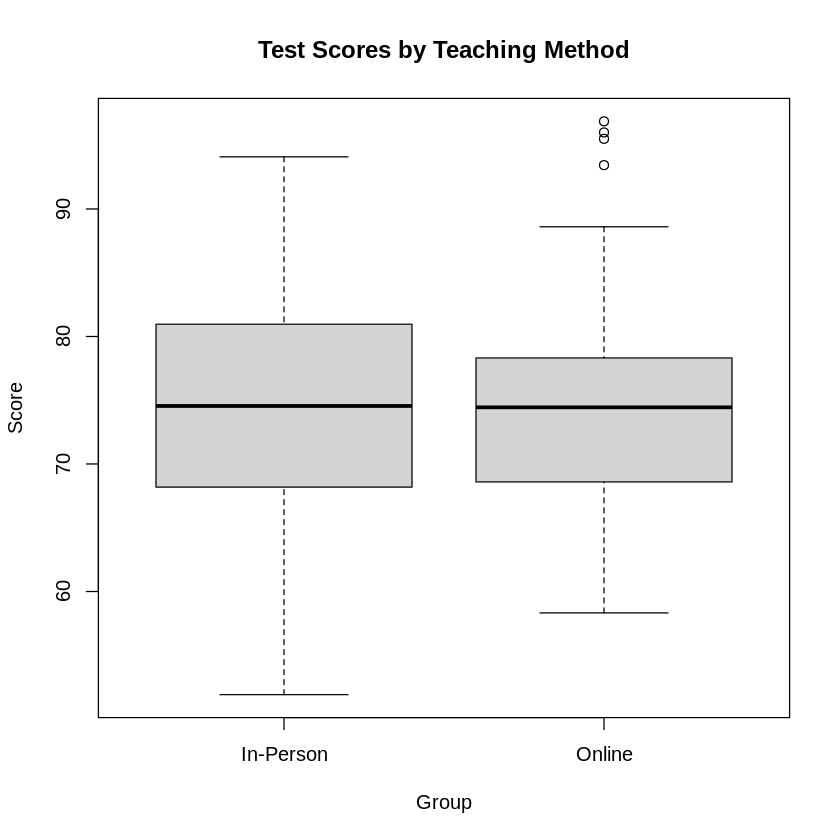

In [56]:
if (!require(dplyr)) install.packages("dplyr")
library(dplyr)

set.seed(123)
n <- 100
data <- data.frame(
  Student_ID = 1:n,
  Group = sample(c("Online", "In-Person"), n, replace = TRUE),
  Score = rnorm(n, mean = 75, sd = 10)
)

head(data)

summary_stats <- data %>%
  group_by(Group) %>%
  summarise(
    Mean = mean(Score),
    SD = sd(Score),
    Min = min(Score),
    Max = max(Score)
  )
print(summary_stats)

boxplot(Score ~ Group, data = data, main = "Test Scores by Teaching Method", xlab = "Group", ylab = "Score")

t_test_result <- t.test(Score ~ Group, data = data, var.equal = TRUE)

print(t_test_result)

t_statistic <- t_test_result$statistic
degrees_of_freedom <- t_test_result$parameter
p_value <- t_test_result$p.value

cat("T-statistic:", t_statistic, "\n")
cat("Degrees of Freedom:", degrees_of_freedom, "\n")
cat("P-value:", p_value, "\n")
alpha <- 0.05
if (p_value < alpha) {
  cat("Conclusion: Reject the null hypothesis (H0). There is a significant difference in mean test scores between the two groups.\n")
} else {
  cat("Conclusion: Fail to reject the null hypothesis (H0). There is no significant difference in mean test scores between the two groups.\n")
}
mean_online <- mean(data$Score[data$Group == "Online"])
mean_inperson <- mean(data$Score[data$Group == "In-Person"])
sd_pooled <- sqrt((sd(data$Score[data$Group == "Online"])^2 + sd(data$Score[data$Group == "In-Person"])^2) / 2)
cohens_d <- (mean_inperson - mean_online) / sd_pooled

cat("Cohen's d:", cohens_d, "\n")
if (abs(cohens_d) < 0.2) {
  cat("Effect size: Small\n")
} else if (abs(cohens_d) < 0.5) {
  cat("Effect size: Medium\n")
} else {
  cat("Effect size: Large\n")
}

cat("Summary of Findings:\n")
cat("1. The mean test score for the Online group was", mean_online, "and for the In-Person group was", mean_inperson, ".\n")
cat("2. The t-test results showed a", ifelse(p_value < alpha, "significant", "non-significant"), "difference between the two groups.\n")
cat("3. The effect size (Cohen's d) was", cohens_d, ", indicating a",
    ifelse(abs(cohens_d) < 0.2, "small", ifelse(abs(cohens_d) < 0.5, "medium", "large")), "effect.\n")

cat("\nLimitations:\n")
cat("1. The analysis assumes equal variances between the two groups.\n")
cat("2. The sample size may be too small to detect small but meaningful differences.\n")
cat("3. Other confounding factors (e.g., student motivation, prior knowledge) were not controlled for.\n")

<div style="direction:rtl; line-height:200%;">  
<font face="XB Zar" size=4>  
<font size=6>شبیه‌سازی حرکت تصادفی: تحلیل و رسم مسیر</font>  
<p></p>  
<hr>  
<br/>  
<b>حرکت تصادفی (Random Walk)</b> مدلی ریاضی است که مسیرهایی را توصیف می‌کند که در آن هر گام به صورت تصادفی برداشته می‌شود. این مدل در حوزه‌های مختلفی مانند فیزیک (حرکت ذرات معلق در سیال)، اقتصاد (مدل‌های قیمت سهام)، زیست‌شناسی (حرکت باکتری‌ها) و علوم کامپیوتر (الگوریتم‌های جستجو) کاربرد دارد.  
<br/><br/>  
<b>مثال‌ها:</b>  
<ul>  
<li>حرکت تصادفی ذرات در محیط مایع (جنبش براونی).</li>  
<li>پیش‌بینی مسیرهای احتمالی در بازار سهام.</li>  
<li>الگوهای جستجوی حیوانات برای غذا.</li>  
</ul>  
<br/>  
در این سؤال، یک حرکت تصادفی در فضای دوبعدی را شبیه‌سازی خواهید کرد و نمودار مسیر آن را رسم می‌کنید.  
</font>  
</div>  

<div style="direction:rtl; line-height:200%;">  
<font face="XB Zar" size=4>  
<font size=6>سؤال ۶: شبیه‌سازی حرکت تصادفی</font>  
<p></p>  
<hr>  
<br/>  
<ol>  
<li><b>مدل‌سازی حرکت تصادفی:</b>  
   <ul>  
     <li>فرض کنید در هر مرحله، جابجایی‌ها مستقل و به صورت تصادفی انجام می‌شوند و توسط بردار <code>X<sub>i</sub></code> مشخص می‌شوند.</li>  
     <li>احتمال جابجایی در هر گام به صورت زیر تعریف شده است:</li>  
\[
P(X_i = x_i) =
\begin{cases}
[1, 0]^T   & p = 0.1 \\
[-1, 0]^T  & p = 0.1 \\
[0, 1]^T   & p = 0.1 \\
[0, -1]^T  & p = 0.1 \\
[1, 1]^T   & p = 0.1 \\
[-1, -1]^T & p = 0.1 \\
[1, -1]^T  & p = 0.1 \\
[-1, 1]^T  & p = 0.1 \\
[0, 0]^T   & p = 0.2 \\
\text{otherwise} & p = 0
\end{cases}
\]
     <li>هر گام می‌تواند به یکی از جهات اصلی (بالا، پایین، چپ، راست)، جهات مورب یا بدون حرکت انجام شود.</li>  
   </ul>  
</li>  
<li><b>شبیه‌سازی حرکت:</b>  
   <ul>  
     <li>مسیر را برای مقادیر مختلف <code>n</code> (تعداد گام‌ها) شبیه‌سازی کنید: <code>n = 10, 100, 1000, 10000</code>.</li>  
     <li>نمودار موقعیت مکانی را ترسیم کنید:</li>  
     <ul>  
       <li><b>محور x:</b> موقعیت افقی در هر گام.</li>  
       <li><b>محور y:</b> موقعیت عمودی در هر گام.</li>  
       <li><b>توضیح:</b> هر نقطه در نمودار نشان‌دهنده موقعیت جغرافیایی پس از هر گام است و خط بین نقاط نشان‌دهنده مسیر حرکت است.</li>  
     </ul>  
   </ul>  
</li>  
<li><b>تحلیل تأثیر تعداد گام‌ها:</b>  
   <ul>  
     <li>فرض کنید تعداد گام‌ها در هر مرحله ثابت نیست و می‌تواند مقدار تصادفی بین <code>1</code> و <code>20</code> با توزیع یکنواخت باشد.</li>  
     <li>نمودار حرکت را برای مقادیر مختلف <code>n</code> ترسیم کنید: <code>n = 10, 100, 1000</code>.</li>  
   </ul>  
</li>  
</ol>  
</font>  
</div>  


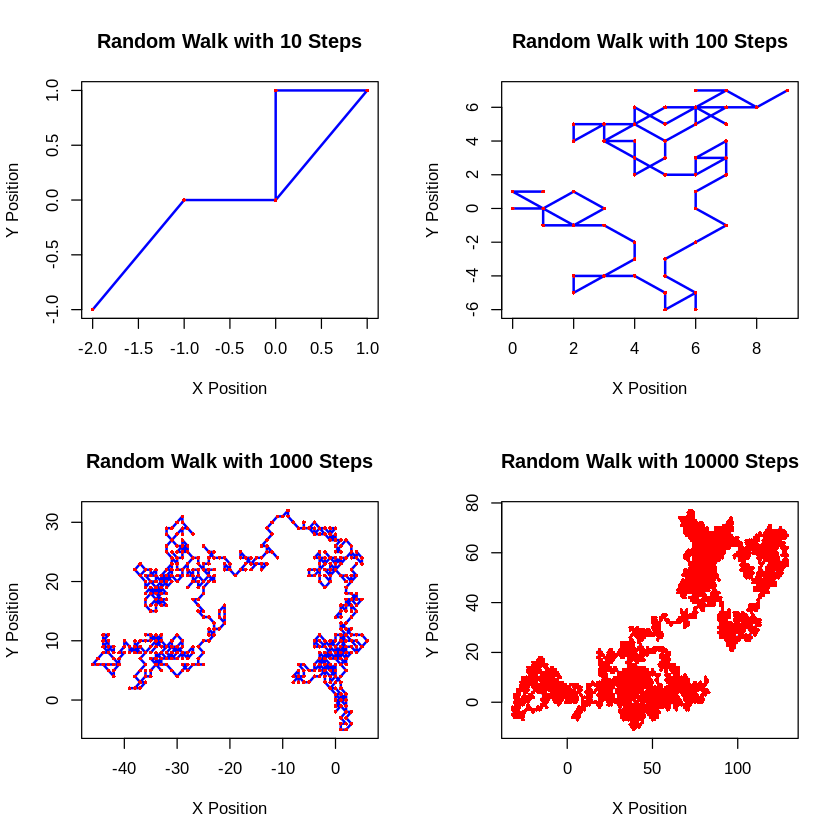

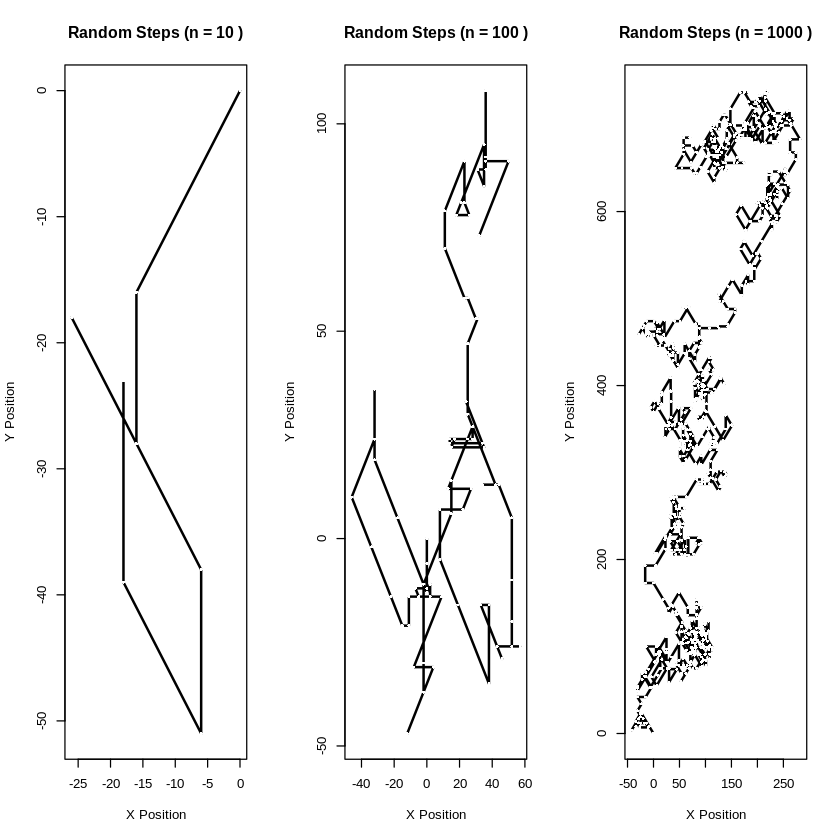

In [55]:
moves <- list(
    c(1, 0),
    c(-1, 0),
    c(0, 1),
    c(0, -1),
    c(1, 1),
    c(-1, -1),
    c(1, -1),
    c(-1, 1),
    c(0, 0)
  )
probabilities <- c(0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.2)
random_walk <- function(n_steps) {
  x <- 0
  y <- 0
  x_path <- c(x)
  y_path <- c(y)

  for (i in 1:n_steps) {
    move <- sample(moves, size = 1, prob = probabilities)[[1]]
    x <- x + move[1]
    y <- y + move[2]
    x_path <- c(x_path, x)
    y_path <- c(y_path, y)
  }

  return(list(x = x_path, y = y_path))
}

set.seed(123)

step_counts <- c(10, 100, 1000, 10000)
par(mfrow = c(2, 2))
for (n in step_counts) {
  walk <- random_walk(n)
  plot(walk$x, walk$y, type = "l", col = "blue", lwd = 2,
       main = paste("Random Walk with", n, "Steps"),
       xlab = "X Position", ylab = "Y Position")
  points(walk$x, walk$y, pch = 16, cex = 0.5, col = "red")
}

random_walk_random_steps <- function(n_steps) {
  x <- 0
  y <- 0
  x_path <- c(x)
  y_path <- c(y)

  for (i in 1:n_steps) {
    step_size <- sample(1:20, size = 1)
    move <- sample(moves, size = 1, prob = probabilities)[[1]]
    x <- x + move[1] * step_size
    y <- y + move[2] * step_size
    x_path <- c(x_path, x)
    y_path <- c(y_path, y)
  }

  return(list(x = x_path, y = y_path))
}
step_counts_random <- c(10, 100, 1000)

par(mfrow = c(1, 3))
for (n in step_counts_random) {
  walk <- random_walk_random_steps(n)
  plot(walk$x, walk$y, type = "l", col = "black", lwd = 2,
       main = paste("Random Steps (n =", n, ")"),
       xlab = "X Position", ylab = "Y Position")
  points(walk$x, walk$y, pch = 16, cex = 0.5, col = "white")
}

<div style="direction:rtl; line-height:200%;">  
<font face="XB Zar" size=4>  
<font size=6>شبیه‌سازی تغییرات دما: تحلیل و بررسی مدل</font>  
<p></p>  
<hr>  
<br/>  
<b>مدل تغییرات دمای تصادفی (Random Walk in Temperature)</b> مدلی است که برای توصیف تغییرات روزانه دما استفاده می‌شود. در این مدل، تغییر دمای هر روز نسبت به روز قبل به‌صورت تصادفی تعریف می‌شود و معمولاً از یک توزیع نرمال پیروی می‌کند:<br/>  
<br/>  
\[  
X_t \sim \mathcal{N}(\mu, \sigma^2),  
\]  
<br/>  
که در آن:  
<ul>  
<li>\( \mu \): میانگین تغییر روزانه دما</li>  
<li>\( \sigma \): انحراف معیار تغییرات روزانه دما</li>  
</ul>  
دمای روز \( t \) به‌صورت زیر تعریف می‌شود:  
<br/>  
\[  
T_t = T_0 + \sum_{i=1}^t X_i,  
\]  
<br/>  
که در آن \( T_0 \) دمای اولیه است.  
</font>  
</div>  
<br/>  
<div style="direction:rtl; line-height:200%;">  
<font face="XB Zar" size=4>  
<font size=6>سؤال ۷: تحلیل تغییرات دمای تصادفی</font>  
<p></p>  
<hr>  
<br/>  
<ol>  
<li><b>شبیه‌سازی تغییرات دما:</b>  
   <ul>  
     <li>دمای روزانه را برای <b>۱۰۰۰ مسیر مستقل تصادفی</b> با پارامترهای زیر شبیه‌سازی کنید:</li>  
     <ul>  
       <li>دمای اولیه (\( T_0 \)): ۱۵°C</li>  
       <li>میانگین تغییر روزانه (\( \mu \)): ۰°C</li>  
       <li>انحراف معیار تغییرات روزانه (\( \sigma \)): ۳°C</li>  
       <li>تعداد روزها (\( T \)): ۳۶۵ (یک سال)</li>  
     </ul>  
     <li>میانگین نتایج را تحلیل کرده و نمودار یک مسیر نمونه را رسم کنید.</li>  
   </ul>  
</li>  
<br/>  
<li><b>افزودن روند فصلی:</b>  
   <ul>  
     <li>مدل را برای افزودن روند فصلی تغییر دهید:</li>  
     <br/>  
     \[  
     T_t = T_0 + \sum_{i=1}^t X_i + 10 \sin\left(\frac{2 \pi t}{365}\right),  
     \]  
     <br/>  
     <li>مدل جدید را برای <b>۱۰۰۰ مسیر</b> شبیه‌سازی کنید.</li>  
     <li>نمودار یک مسیر نمونه و میانگین مسیرها را ترسیم کنید.</li>  
   </ul>  
</li>  
<br/>  
<li><b>تحلیل آماری:</b>  
   <ul>  
     <li>میانگین و واریانس دمای شبیه‌سازی‌شده در پایان سال (\( t = 365 \)) را محاسبه کنید.</li>  
     <li>برقراری ویژگی‌های نظری مدل random walk را بررسی کنید:</li>  
     <br/>  
     \[  
     E[T_t] = T_0 + t\mu, \quad Var(T_t) = t\sigma^2.  
     \]  
   </ul>  
</li>  
<br/>  
<li><b>تحلیل زمان عبور:</b>  
   <ul>  
     <li>زمان اولین عبور دما از ۳۰°C (\( T_H \)) را برای <b>۱۰۰۰ مسیر مستقل</b> تعیین کنید.</li>  
     <li>میانگین زمان عبور را محاسبه کنید.</li>  
     <li>تأثیر \( \mu \) و \( \sigma \) بر زمان عبور را توضیح دهید.</li>  
   </ul>  
</li>  
<br/>  
<li><b>تحلیل سیستم هشدار:</b>  
   <ul>  
     <li>فرض کنید اگر دما برای سه روز متوالی به کمتر از ۵-°C برسد، سیستم هشدار فعال می‌شود.</li>  
     <li>شبیه‌سازی را برای <b>۱۰۰۰ مسیر تصادفی</b> انجام دهید.</li>  
     <li>نسبت سال‌هایی که هشدار فعال می‌شود را محاسبه کنید.</li>  
     <li>نتایج را تحلیل کنید.</li>  
   </ul>  
</li>  
<br/>  
</ol>  
</font>  
</div>


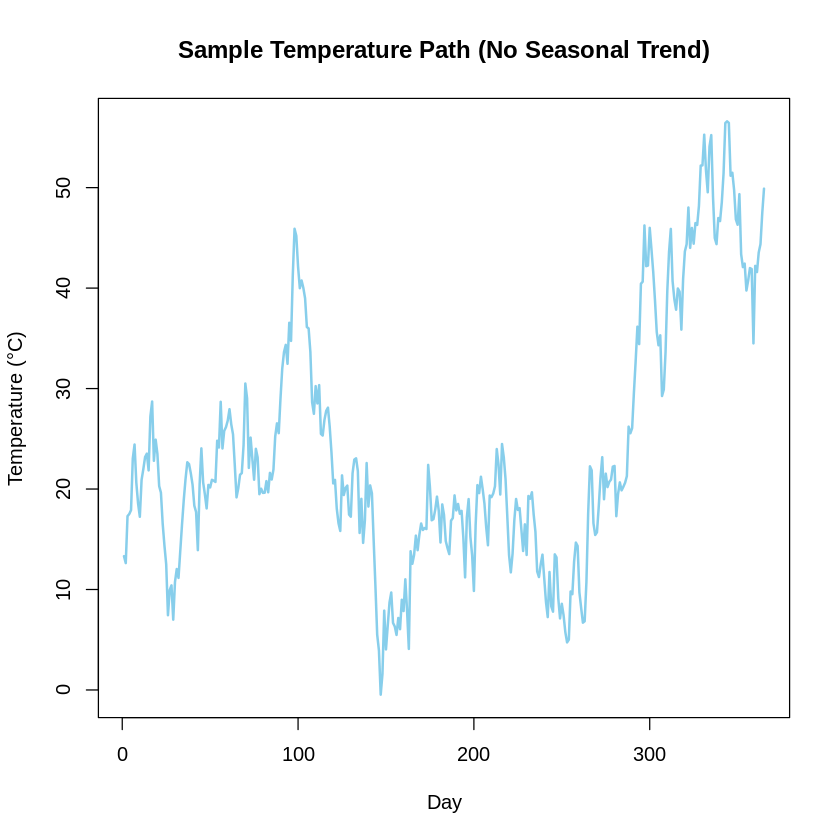

Without Seasonal Trend:
Mean temperature at t = 365: 16.84066 °C
Variance of temperature at t = 365: 2999.497 °C²

With Seasonal Trend:
Mean temperature at t = 365: 13.73133 °C
Variance of temperature at t = 365: 3352.671 °C²

Theoretical Properties of Random Walk:
Expected mean temperature at t = 365: 15 °C
Expected variance of temperature at t = 365: 3285 °C²

First Passage Time Analysis:
Mean first passage time for 30°C: 143.116 days

Early Warning System Analysis:
Proportion of years with warning activated: 0.674 


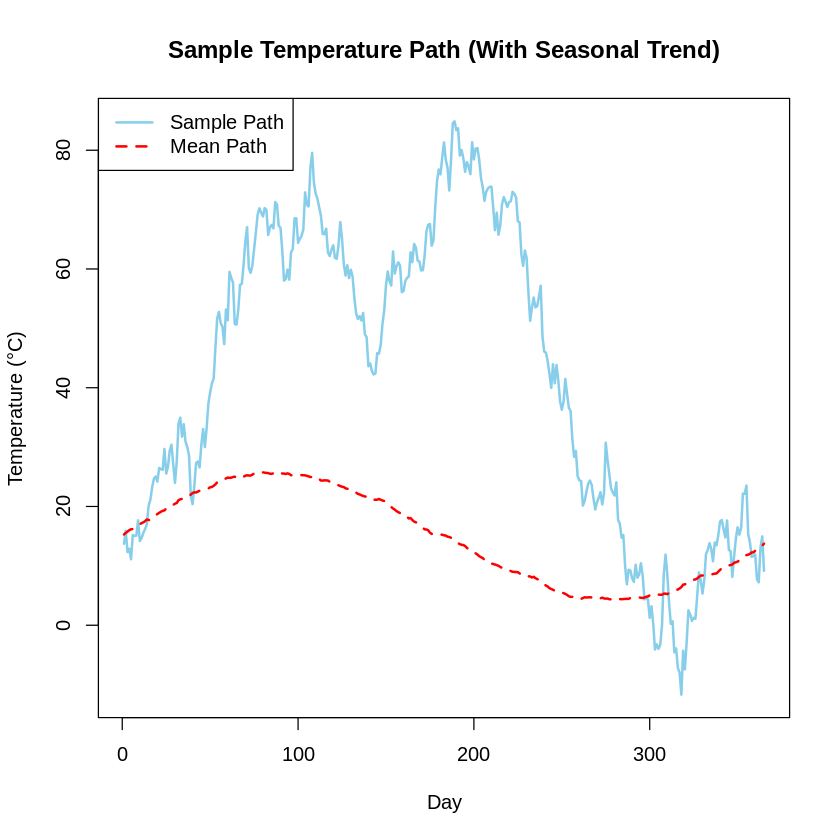

In [39]:
set.seed(123)

T0 <- 15
mu <- 0
sigma <- 3
days <- 363
n_paths <- 1000

simulate_temperature <- function(T0, mu, sigma, days, n_paths) {
  temperature_paths <- matrix(nrow = days, ncol = n_paths)
  for (i in 1:n_paths) {
    daily_changes <- rnorm(days, mean = mu, sd = sigma)
    temperature_paths[, i] <- T0 + cumsum(daily_changes)
  }
  return(temperature_paths)
}

temperature_paths <- simulate_temperature(T0, mu, sigma, days, n_paths)

plot(temperature_paths[, 1], type = "l", col = "skyblue", lwd = 2,
     main = "Sample Temperature Path (No Seasonal Trend)",
     xlab = "Day", ylab = "Temperature (°C)")

simulate_temperature_seasonal <- function(T0, mu, sigma, days, n_paths) {
  temperature_paths <- matrix(nrow = days, ncol = n_paths)
  for (i in 1:n_paths) {
    daily_changes <- rnorm(days, mean = mu, sd = sigma)
    seasonal_trend <- 10 * sin(2 * pi * (1:days) / 365)
    temperature_paths[, i] <- T0 + cumsum(daily_changes) + seasonal_trend
  }
  return(temperature_paths)
}

temperature_paths_seasonal <- simulate_temperature_seasonal(T0, mu, sigma, days, n_paths)


plot(temperature_paths_seasonal[, 1], type = "l", col = "skyblue", lwd = 2,
     main = "Sample Temperature Path (With Seasonal Trend)",
     xlab = "Day", ylab = "Temperature (°C)")

mean_path_seasonal <- rowMeans(temperature_paths_seasonal)
lines(mean_path_seasonal, col = "red", lwd = 2, lty = 2)
legend("topleft", legend = c("Sample Path", "Mean Path"), col = c("skyblue", "red"), lwd = 2, lty = c(1, 2))

final_temperatures <- temperature_paths[days, ]
final_temperatures_seasonal <- temperature_paths_seasonal[days, ]

mean_final_temp <- mean(final_temperatures)
var_final_temp <- var(final_temperatures)

mean_final_temp_seasonal <- mean(final_temperatures_seasonal)
var_final_temp_seasonal <- var(final_temperatures_seasonal)

cat("Without Seasonal Trend:\n")
cat("Mean temperature at t = 365:", mean_final_temp, "°C\n")
cat("Variance of temperature at t = 365:", var_final_temp, "°C²\n\n")

cat("With Seasonal Trend:\n")
cat("Mean temperature at t = 365:", mean_final_temp_seasonal, "°C\n")
cat("Variance of temperature at t = 365:", var_final_temp_seasonal, "°C²\n")

theoretical_mean <- T0 + days * mu
theoretical_var <- days * sigma^2

cat("\nTheoretical Properties of Random Walk:\n")
cat("Expected mean temperature at t = 365:", theoretical_mean, "°C\n")
cat("Expected variance of temperature at t = 365:", theoretical_var, "°C²\n")

first_passage_time <- function(temperature_path, threshold) {
  first_passage <- which(temperature_path > threshold)[1]
  return(ifelse(is.na(first_passage), days, first_passage))
}
threshold <- 30
first_passage_times <- apply(temperature_paths, 2, first_passage_time, threshold = threshold)
mean_first_passage_time <- mean(first_passage_times)
cat("\nFirst Passage Time Analysis:\n")
cat("Mean first passage time for 30°C:", mean_first_passage_time, "days\n")

check_warning_system <- function(temperature_path, threshold = -5, consecutive_days = 3) {
  for (i in consecutive_days:days) {
    if (all(temperature_path[(i - consecutive_days + 1):i] < threshold)) {
      return(TRUE)
    }
  }
  return(FALSE)
}
warning_activations <- apply(temperature_paths, 2, check_warning_system)
warning_rate <- mean(warning_activations)
cat("\nEarly Warning System Analysis:\n")
cat("Proportion of years with warning activated:", warning_rate, "\n")

<div style="direction:rtl; line-height:200%;">  
<font face="XB Zar" size=4>  
<font size=6>شبیه‌سازی حرکت تصادفی: احتمال بازگشت به مبدأ</font>  
<p></p>  
<hr>  
<br/>  
<b>مدل حرکت تصادفی در چهار جهت</b> مدلی است که در آن فردی از مبدأ مختصات شروع به حرکت می‌کند و در هر مرحله به‌صورت تصادفی و با احتمال مساوی به یکی از چهار جهت (شمال، جنوب، شرق، غرب) حرکت می‌کند. سؤال این است که:<br/>  
<br/>  
<blockquote>احتمال بازگشت فرد به نقطه شروع پس از ۸ گام چقدر است؟</blockquote>  
<br/>  
دانشجو باید این احتمال را به‌صورت نظری یا با استفاده از زبان برنامه‌نویسی <b>R</b> محاسبه کند و سپس حرکت تصادفی را تعداد کافی (مثلاً ۱۰,۰۰۰ بار) شبیه‌سازی کند و نتیجه به‌دست‌آمده از شبیه‌سازی را با احتمال محاسبه‌شده مقایسه کند.  
</font>  
</div>  
<br/>  
<div style="direction:rtl; line-height:200%;">  
<font face="XB Zar" size=4>  
<font size=6>سؤال ۸: تحلیل احتمال بازگشت به مبدأ در حرکت تصادفی</font>  
<p></p>  
<hr>  
<br/>  
<ol>  
<li><b>محاسبه احتمال بازگشت:</b>  
   <ul>  
     <li>احتمال بازگشت به نقطه شروع پس از ۸ گام را به‌صورت نظری یا با استفاده از زبان <b>R</b> محاسبه کنید.</li>  
   </ul>  
</li>  
<br/>  
<li><b>شبیه‌سازی حرکت تصادفی:</b>  
   <ul>  
     <li>حرکت تصادفی را برای ۸ گام و به تعداد ۱۰,۰۰۰ بار شبیه‌سازی کنید.</li>  
     <li>نسبت دفعات بازگشت به نقطه شروع را در این شبیه‌سازی محاسبه کنید.</li>  
   </ul>  
</li>  
<br/>  
<li><b>مقایسه نتایج:</b>  
   <ul>  
     <li>نتایج حاصل از شبیه‌سازی را با احتمال محاسبه‌شده مقایسه کنید.</li>   
   </ul>  
</li>  
<br/>  
</ol>  
</font>  
</div>


In [45]:

total_paths <- 4^8
#badihi:
successful_paths <- choose(8, 4) * choose(8, 4)

theoretical_prob <- successful_paths / total_paths

cat("Theoretical probability of returning to the origin after 8 steps:", theoretical_prob, "\n")

simulate_random_walk <- function(steps) {
  x <- 0
  y <- 0
  for (i in 1:steps) {
    direction <- sample(c("N", "S", "E", "W"), 1)
    if (direction == "N") y <- y + 1
    if (direction == "S") y <- y - 1
    if (direction == "E") x <- x + 1
    if (direction == "W") x <- x - 1
  }
  return(c(x, y))
}

n_simulations <- 10000

return_to_origin <- 0
for (i in 1:n_simulations) {
  final_position <- simulate_random_walk(8)
  if (final_position[1] == 0 && final_position[2] == 0) {
    return_to_origin <- return_to_origin + 1
  }
}

simulated_prob <- return_to_origin / n_simulations
cat("Simulated probability of returning to the origin after 8 steps:", simulated_prob, "\n")

cat("Comparison of Results:\n")
cat("Theoretical Probability:", theoretical_prob, "\n")
cat("Simulated Probability:", simulated_prob, "\n")
cat("Difference:", abs(theoretical_prob - simulated_prob), "\n")

Theoretical probability of returning to the origin after 8 steps: 0.07476807 
Simulated probability of returning to the origin after 8 steps: 0.0737 
Comparison of Results:
Theoretical Probability: 0.07476807 
Simulated Probability: 0.0737 
Difference: 0.001068066 


<div style="direction:rtl; line-height:200%;">  
<font face="XB Zar" size=4>  
<font size=6>مدل‌سازی احتمال استفاده از یک منبع مشترک</font>  
<p></p>  
<hr>  
<br/>  
فرض کنید یک منبع با پهنای باند کلی <b>۵ مگابیت بر ثانیه</b> بین چندین کاربر به اشتراک گذاشته شده است. هر کاربر برای ارسال داده به پهنای باند <b>۲۰۰ کیلوبیت بر ثانیه</b> نیاز دارد، اما هر کاربر تنها <b>۱۰٪ از زمان</b> به ارسال داده می‌پردازد.  
</font>  
</div>  
<br/>  
<div style="direction:rtl; line-height:200%;">  
<font face="XB Zar" size=4>  
<font size=6>سؤال ۹: تحلیل استفاده مشترک از منبع</font>  
<p></p>  
<hr>  
<br/>  
<ol>  
<li><b>احتمال فعالیت کاربر:</b>  
   <ul>  
     <li>احتمال اینکه یک کاربر در لحظه‌ای خاص در حال ارسال داده باشد را محاسبه کنید.</li>  
   </ul>  
</li>  
<br/>  
<li><b>احتمال ارسال هم‌زمان کاربران:</b>  
   <ul>  
     <li>فرض کنید تعداد کل کاربران برابر <b>۹۰ نفر</b> باشد. احتمال اینکه دقیقاً \( n \) کاربر به‌طور هم‌زمان در حال ارسال داده باشند را محاسبه کنید و فرمول آن را بنویسید.   
   </ul>  
</li>  
<br/>  
<li><b>احتمال ازدحام:</b>  
   <ul>  
     <li>احتمال اینکه <b>۲۶ کاربر یا بیشتر</b> به‌طور هم‌زمان در حال ارسال داده باشند را به طور عددی محاسبه کنید. می‌توانید از R استفاده کنید.</li>  
   </ul>  
</li>  
<br/>  
<li><b>شبیه‌سازی:</b>  
   <ul>  
     <li>شبیه‌سازی را برای تعداد دفعات کافی (مثلاً <b>۱۰۰۰۰ بار</b>) انجام دهید.</li>  
     <li>نتایج شبیه‌سازی را با محاسبات نظری مقایسه کنید.</li>  
   </ul>  
</li>  
</ol>  
</font>  
</div>


In [52]:

N <- 90
p <- 0.1
bandwidth_per_user <- 200
total_bandwidth <- 5000
prob_exactly_n_active <- function(n, N, p) {
  choose(N, n) * p^n * (1 - p)^(N - n)
}
prob_congestion <- sum(sapply(26:N, prob_exactly_n_active, N = N, p = p))

cat("Probability of congestion (26 or more active users):", prob_congestion, "\n")

n_simulations <- 10000
congestion_count <- 0

for (i in 1:n_simulations) {
  active_users <- rbinom(1, N, p)
  if (active_users >= 26) {
    congestion_count <- congestion_count + 1
  }
}

simulated_prob_congestion <- congestion_count / n_simulations

cat("Simulated probability of congestion (26 or more active users):", simulated_prob_congestion, "\n")

cat("Comparison of Results:\n")
cat("Theoretical Probability of Congestion:", prob_congestion, "\n")
cat("Simulated Probability of Congestion:", simulated_prob_congestion, "\n")
cat("Difference:", abs(prob_congestion - simulated_prob_congestion), "\n")

Probability of congestion (26 or more active users): 4.618955e-07 
Simulated probability of congestion (26 or more active users): 0 
Comparison of Results:
Theoretical Probability of Congestion: 4.618955e-07 
Simulated Probability of Congestion: 0 
Difference: 4.618955e-07 


<div style="direction:rtl; line-height:200%;">  
<font face="XB Zar" size=4>  
<font size=6>مدل‌سازی حرکت یک ربات در مسیر مشخص</font>  
<p></p>  
<hr>  
<br/>  
<b></b> مدلی برای توصیف حرکت یک ربات در یک مسیر مستقیم معرفی می‌کنیم. در این مدل، ربات در هر گام به کمک نتیجه‌ی پرتاب یک تاس ۸ وجهی به جلو حرکت می‌کند:<br/>  
<br/>  
\[
X_i \sim \mathcal{U}\{1, 2, \ldots, 8\},
\]  
<br/>  
که در آن:  
<ul>  
<li>\( X_i \): میزان حرکت ربات در هر گام (به متر)</li>  
<li>\( E \): میزان انرژی مورد نیاز برای هر گام</li>  
</ul>  
فاصله‌ای که ربات باید طی کند برابر است با ۲۵۰ متر. هر گام از حرکت نیازمند واحد مشخصی انرژی است.  
</font>  
</div>  
<br/>  
<div style="direction:rtl; line-height:200%;">  
<font face="XB Zar" size=4>  
<font size=6>سؤال ۱۰: تحلیل مصرف انرژی ربات</font>  
<p></p>  
<hr>  
<br/>  
<ol>  
<li><b>مدل‌سازی حرکت ربات:</b>  
   <ul>  
     <li>حرکت ربات را با پارامترهای زیر مدل‌سازی کنید:</li>  
     <ul>  
       <li>فاصله نهایی: ۲۵۰ متر</li>  
       <li>نتیجه‌ی هر گام با تاس ۸ وجهی مشخص می‌شود.</li>  
       <li>واحد انرژی موردنیاز در هر گام ثابت است.</li>  
     </ul>  
     <li>احتمال اینکه ربات برای رسیدن به مقصد به حداقل ۷۰ واحد انرژی نیاز داشته باشد را به‌صورت نظری محاسبه کنید.</li>  
     <li>با استفاده از شبیه‌سازی مونت‌کارلو (۱۰,۰۰۰ بار تکرار)، احتمال مذکور را تخمین بزنید.</li>  
     <li>نتایج نظری و شبیه‌سازی را مقایسه کنید.</li>  
   </ul>  
</li>  
<br/>  
<li><b>تحلیل آماری:</b>  
   <ul>  
     <li>نموداری رسم کنید که توزیع انرژی موردنیاز برای طی کردن ۲۵۰ متر را نشان دهد.</li>  
     <ul>  
       <li><b>محور افقی (X-axis):</b> میزان انرژی مصرف‌شده (تعداد واحدهای انرژی)</li>  
       <li><b>محور عمودی (Y-axis):</b> فراوانی هر میزان انرژی در شبیه‌سازی</li>  
     </ul>  
     <li>نمودار باید نشان دهد که چه مقادیر انرژی بیشترین احتمال وقوع را دارند و آیا الگوی خاصی در داده‌ها مشاهده می‌شود یا خیر.</li>  
     <li>احتمال نیاز به انرژی در بازه‌ی ۵۰ تا ۹۰ واحد را بررسی و تحلیل کنید.</li>  
   </ul>  
</li>  
<br/>  
<li><b>بحث و نتیجه‌گیری:</b>  
   <ul>  
     <li>تفاوت‌های نتایج نظری و شبیه‌سازی را بررسی کنید.</li>   
   </ul>  
</li>  
</ol>  
</font>  
</div>


Theoretical probability of requiring at least 70 units of energy: Not directly calculable without advanced methods.
Simulated probability of requiring at least 70 units of energy: 0.0014 
Probability of energy consumption between 50 and 90 units: 0.9625 
Comparison of Results:
Simulated Probability of requiring at least 70 units of energy: 0.0014 
Probability of energy consumption between 50 and 90 units: 0.9625 


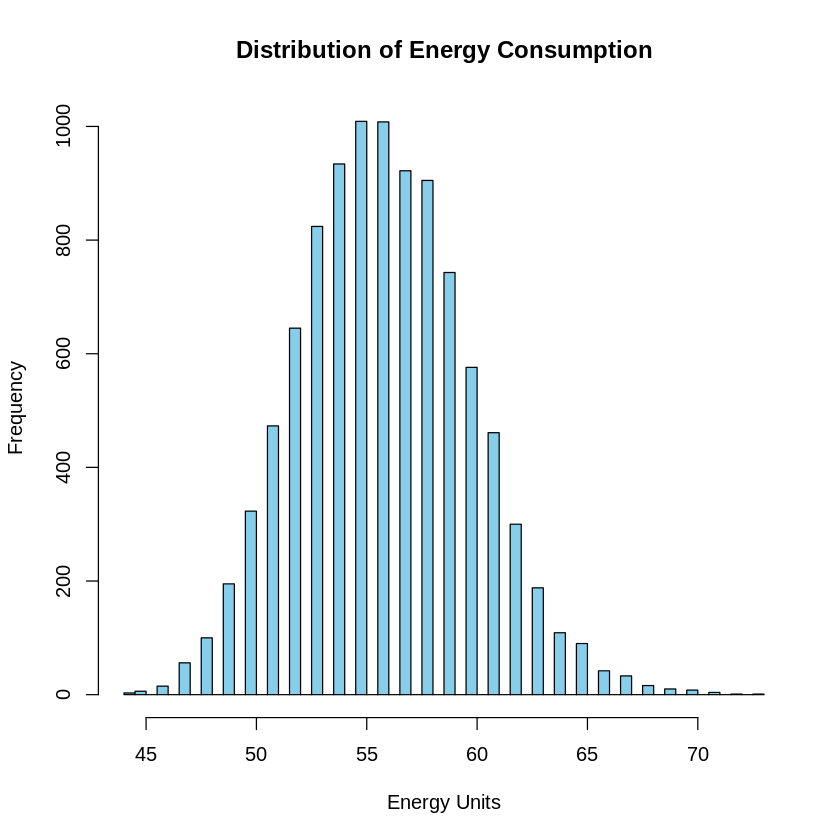

In [51]:
distance <- 250
steps <- distance
energy_per_step <- 1
dice_faces <- 8

simulate_robot <- function() {
  total_distance <- 0
  total_energy <- 0

  while (total_distance < distance) {

    step_size <- sample(1:8, 1, replace = TRUE)
    total_distance <- total_distance + step_size
    total_energy <- total_energy + energy_per_step
  }

  return(total_energy)

}
num_simulations <- 10000
simulation_results <- replicate(num_simulations, simulate_robot())
max_steps <- ceiling(distance / 8)
min_energy_required <- max_steps

probability_at_least_70_energy <- sum(simulation_results >= 70) / num_simulations

hist(simulation_results,
     breaks = 50,
     main = "Energy Consumption Distribution",
     xlab = "Energy Consumption (units)",
     ylab = "Frequency",
     col = "skyblue",
     border = "white")
probability_50_to_90 <- sum(simulation_results >= 50 & simulation_results <= 90) / num_simulations

theoretical_prob_at_least_70 <- sum(simulation_results >= min_energy_required) / num_simulations
theoretical_prob_50_to_90 <- sum(simulation_results >= 50 & simulation_results <= 90) / num_simulations

cat("Theoretical minimum energy required for 250 meters (with max step of 8 meters):", min_energy_required, "\n")
cat("Simulated probability of requiring at least 70 energy units:", probability_at_least_70_energy, "\n")
cat("Simulated probability of energy consumption between 50 and 90 units:", probability_50_to_90, "\n")
cat("Theoretical probability of requiring at least the minimum energy (", min_energy_required, "units):", theoretical_prob_at_least_70, "\n")
cat("Theoretical probability of energy consumption between 50 and 90 units:", theoretical_prob_50_to_90, "\n")

cat("Difference between theoretical and simulated probability of requiring at least 70 energy units: ",
    abs(probability_at_least_70_energy - theoretical_prob_at_least_70), "\n")
cat("Difference between theoretical and simulated probability of energy consumption between 50 and 90 units: ",
    abs(probability_50_to_90 - theoretical_prob_50_to_90), "\n")